In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

In [2]:
sns.set_style("ticks")

# Repositories Analysis

This notebook contains analysis of popular GitHub repositories.

The analysis is based on lists of top 5000 repositories by the number of stars and top 5000 repositories by the number of forks.
The data were obtained on 2024-07-14 using scripts in the repository.

## Preparation

We start by loading a list of top 5000 repositories by stars and a list of top 5000 repositories by forks.

In [3]:
repositories_by_stars = pd.read_json("../data/repositories-by-stars.json")
repositories_by_stars.set_index("id", inplace=True)

In [4]:
repositories_by_stars.sort_values(by="stargazers_count", ascending=False)

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
28457823,freeCodeCamp,freeCodeCamp,https://github.com/freeCodeCamp/freeCodeCamp,449544,main,BSD-3-Clause,TypeScript,"{'TypeScript': 2268093, 'JavaScript': 954807, ...",freeCodeCamp.org's open-source codebase and cu...,http://contribute.freecodecamp.org/intro,...,236,True,False,False,False,True,True,False,False,False
13491895,EbookFoundation,free-programming-books,https://github.com/EbookFoundation/free-progra...,18628,main,CC-BY-4.0,None,{},:books: Freely available programming books,https://ebookfoundation.github.io/free-program...,...,35,True,False,False,True,False,True,False,False,False
21737465,sindresorhus,awesome,https://github.com/sindresorhus/awesome,1517,main,CC0-1.0,None,{},😎 Awesome lists about all kinds of interesting...,None,...,38,True,False,False,True,False,True,False,False,False
54346799,public-apis,public-apis,https://github.com/public-apis/public-apis,5010,master,MIT,Python,"{'Python': 40479, 'Shell': 1352}",A collective list of free APIs,https://APILayer.com/?utm_source=Github&utm_me...,...,289,True,False,False,False,False,True,False,False,False
60493101,jwasham,coding-interview-university,https://github.com/jwasham/coding-interview-un...,22281,main,CC-BY-SA-4.0,None,{},A complete computer science study plan to beco...,None,...,44,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098927,robertkrimen,otto,https://github.com/robertkrimen/otto,2263,master,MIT,Go,"{'Go': 1006774, 'Perl': 1604}",A JavaScript interpreter in Go (golang),http://godoc.org/github.com/robertkrimen/otto,...,44,True,False,True,False,True,True,False,False,False
3087541,patrickmn,go-cache,https://github.com/patrickmn/go-cache,126,master,MIT,Go,{'Go': 76573},An in-memory key:value store/cache (similar to...,https://patrickmn.com/projects/go-cache/,...,70,True,False,True,False,True,True,False,False,False
558443197,OdysseusYuan,LKY_OfficeTools,https://github.com/OdysseusYuan/LKY_OfficeTools,49445,master,GPL-3.0,C#,{'C#': 236846},一键自动化 下载、安装、激活 Office 的利器。,Email: OdysseusYuan@foxmail.com,...,2,True,True,True,False,True,True,False,False,False


In [5]:
repositories_by_forks = pd.read_json("../data/repositories-by-forks.json")
repositories_by_forks.set_index("id", inplace=True)

In [6]:
repositories_by_forks.sort_values(by="forks_count", ascending=False)

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
14204342,jtleek,datasharing,https://github.com/jtleek/datasharing,590,master,None,None,{},The Leek group guide to data sharing,None,...,893,True,False,True,False,True,True,False,False,False
1300192,octocat,Spoon-Knife,https://github.com/octocat/Spoon-Knife,2,main,None,HTML,"{'HTML': 355, 'CSS': 256}",This repo is for demonstration purposes only.,None,...,17559,True,False,True,False,True,True,False,False,False
15917132,rdpeng,ProgrammingAssignment2,https://github.com/rdpeng/ProgrammingAssignment2,6670,master,None,R,{'R': 324},Repository for Programming Assignment 2 for R ...,None,...,4215,True,False,True,False,True,True,False,False,False
40212802,SmartThingsCommunity,SmartThingsPublic,https://github.com/SmartThingsCommunity/SmartT...,21066,master,None,Groovy,"{'Groovy': 5372198, 'Shell': 655}",SmartThings open-source DeviceType Handlers an...,https://developer-preview.smartthings.com/docs...,...,2512,True,False,True,False,True,True,False,False,False
121291758,Pierian-Data,Complete-Python-3-Bootcamp,https://github.com/Pierian-Data/Complete-Pytho...,37125,master,None,Jupyter Notebook,"{'Jupyter Notebook': 35097216, 'Python': 1767}",Course Files for Complete Python 3 Bootcamp Co...,None,...,226,True,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111194705,nestjs,docs.nestjs.com,https://github.com/nestjs/docs.nestjs.com,55344,master,MIT,TypeScript,"{'TypeScript': 154284, 'SCSS': 43993, 'JavaScr...",The official documentation https://docs.nestjs...,None,...,169,True,False,True,False,True,True,False,False,False
326713486,css-for-js,character-creator,https://github.com/css-for-js/character-creator,4733,main,NOASSERTION,JavaScript,"{'JavaScript': 10249, 'CSS': 2415, 'HTML': 716}",None,None,...,6,True,False,True,False,True,True,False,False,False
63705439,learn-co-students,javascript-arithmetic-lab-js-intro-000,https://github.com/learn-co-students/javascrip...,22,master,NOASSERTION,JavaScript,"{'JavaScript': 2509, 'HTML': 786}",None,None,...,1869,True,False,False,False,True,True,False,False,False


We merge the two lists to get a list of popular repositories by either of these two metrics.

In [7]:
df = pd.concat([repositories_by_stars, repositories_by_forks])
df = df.groupby(df.index).first()

In [8]:
df

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
3282,preservim,nerdtree,https://github.com/preservim/nerdtree,1995,master,WTFPL,Vim Script,{'Vim Script': 217175},A tree explorer plugin for vim.,None,...,20,True,False,True,False,False,True,False,False,False
3314,spree,spree,https://github.com/spree/spree,155135,main,BSD-3-Clause,Ruby,"{'Ruby': 3046097, 'HTML': 26893, 'Shell': 4764...",An open source eCommerce platform giving you f...,https://spreecommerce.org,...,307,True,True,False,False,True,True,False,False,False
8393,thoughtbot,paperclip,https://github.com/thoughtbot/paperclip,3579,main,NOASSERTION,Ruby,"{'Ruby': 522650, 'Gherkin': 8317, 'HTML': 407}",Easy file attachment management for ActiveRecord,https://thoughtbot.com,...,54,True,False,True,False,False,True,False,False,True
8514,rails,rails,https://github.com/rails/rails,280094,main,MIT,Ruby,"{'Ruby': 16757609, 'JavaScript': 216319, 'HTML...",Ruby on Rails,https://rubyonrails.org,...,1201,True,True,False,False,True,True,False,False,False
15435,Shopify,liquid,https://github.com/Shopify/liquid,5705,main,MIT,Ruby,"{'Ruby': 467586, 'Liquid': 72882}","Liquid markup language. Safe, customer facing ...",https://shopify.github.io/liquid/,...,354,True,False,True,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808045485,LadybirdBrowser,ladybird,https://github.com/LadybirdBrowser/ladybird,226351,master,BSD-2-Clause,C++,"{'C++': 24568535, 'JavaScript': 2309458, 'HTML...",Truly independent web browser,https://ladybird.org,...,152,True,False,False,False,False,True,False,False,False
812323913,tech-shrimp,docker_image_pusher,https://github.com/tech-shrimp/docker_image_pu...,734,main,Apache-2.0,None,{},使用Github Action将国外的Docker镜像转存到阿里云私有仓库，供国内服务器使用...,None,...,62,True,False,True,False,True,True,False,False,False
813254316,cmliu,CF-Workers-docker.io,https://github.com/cmliu/CF-Workers-docker.io,25,main,None,JavaScript,{'JavaScript': 9865},这个项目是一个基于 Cloudflare Workers 的 Docker 镜像代理工具。它...,https://docker.fxxk.dedyn.io,...,11,True,False,False,False,True,True,False,False,False


In [9]:
# Repositories that are both in top 5000 by stars and by forks
df[df.index.isin(repositories_by_stars.index) & df.index.isin(repositories_by_forks.index)]

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
3314,spree,spree,https://github.com/spree/spree,155135,main,BSD-3-Clause,Ruby,"{'Ruby': 3046097, 'HTML': 26893, 'Shell': 4764...",An open source eCommerce platform giving you f...,https://spreecommerce.org,...,307,True,True,False,False,True,True,False,False,False
8514,rails,rails,https://github.com/rails/rails,280094,main,MIT,Ruby,"{'Ruby': 16757609, 'JavaScript': 216319, 'HTML...",Ruby on Rails,https://rubyonrails.org,...,1201,True,True,False,False,True,True,False,False,False
26554,reddit-archive,reddit,https://github.com/reddit-archive/reddit,40093,master,NOASSERTION,Python,"{'Python': 3814709, 'JavaScript': 1878352, 'HT...",historical code from reddit.com,None,...,304,False,False,True,False,True,False,False,False,True
34096,leachim6,hello-world,https://github.com/leachim6/hello-world,5294,main,MIT,Assembly,"{'Assembly': 21160, 'Python': 5039, 'C': 2355,...",Hello world in every computer language. Thank...,http://github.com/leachim6/hello-world/wikis,...,66,True,False,True,False,True,True,False,False,False
36502,git,git,https://github.com/git/git,252733,master,NOASSERTION,C,"{'C': 11058749, 'Shell': 8473599, 'Perl': 1161...",Git Source Code Mirror - This is a publish-onl...,None,...,186,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773286980,xai-org,grok-1,https://github.com/xai-org/grok-1,1008,main,Apache-2.0,Python,{'Python': 77280},Grok open release,None,...,96,True,True,True,False,True,True,False,False,False
774650660,hydralauncher,hydra,https://github.com/hydralauncher/hydra,38424,main,MIT,TypeScript,"{'TypeScript': 354745, 'Python': 5812, 'JavaSc...",Hydra is a game launcher with its own embedded...,None,...,179,True,False,True,False,True,True,False,False,False
775250190,stitionai,devika,https://github.com/stitionai/devika,6132,main,MIT,Python,"{'Python': 125021, 'Svelte': 48724, 'Jinja': 1...",Devika is an Agentic AI Software Engineer that...,None,...,149,True,True,False,False,True,True,False,False,False


In [10]:
# Repositories that are only in top 5000 by stars
df[df.index.isin(repositories_by_stars.index) & ~df.index.isin(repositories_by_forks.index)].sort_values(by="stargazers_count", ascending=False)

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
196701619,tauri-apps,tauri,https://github.com/tauri-apps/tauri,85503,dev,Apache-2.0,Rust,"{'Rust': 2158943, 'TypeScript': 188102, 'NSIS'...","Build smaller, faster, and more secure desktop...",https://tauri.app,...,885,True,True,False,False,True,True,False,False,False
1334369,resume,resume.github.com,https://github.com/resume/resume.github.com,411,master,None,JavaScript,"{'JavaScript': 19277, 'HTML': 15229, 'CSS': 73...",Resumes generated using the GitHub informations,https://resume.github.com,...,67,True,False,True,True,True,True,False,False,False
163883279,nektos,act,https://github.com/nektos/act,9966,master,MIT,Go,"{'Go': 735944, 'JavaScript': 168741, 'Shell': ...",Run your GitHub Actions locally 🚀,https://nektosact.com,...,208,True,True,False,False,True,True,False,False,False
130464961,sharkdp,bat,https://github.com/sharkdp/bat,31141,master,Apache-2.0,Rust,"{'Rust': 407186, 'Python': 8968, 'Shell': 3653...",A cat(1) clone with wings.,None,...,309,True,True,False,False,False,True,False,False,False
138547797,FiloSottile,mkcert,https://github.com/FiloSottile/mkcert,1799,master,BSD-3-Clause,Go,{'Go': 41331},A simple zero-config tool to make locally trus...,https://mkcert.dev,...,142,True,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098927,robertkrimen,otto,https://github.com/robertkrimen/otto,2263,master,MIT,Go,"{'Go': 1006774, 'Perl': 1604}",A JavaScript interpreter in Go (golang),http://godoc.org/github.com/robertkrimen/otto,...,44,True,False,True,False,True,True,False,False,False
3087541,patrickmn,go-cache,https://github.com/patrickmn/go-cache,126,master,MIT,Go,{'Go': 76573},An in-memory key:value store/cache (similar to...,https://patrickmn.com/projects/go-cache/,...,70,True,False,True,False,True,True,False,False,False
558443197,OdysseusYuan,LKY_OfficeTools,https://github.com/OdysseusYuan/LKY_OfficeTools,49445,master,GPL-3.0,C#,{'C#': 236846},一键自动化 下载、安装、激活 Office 的利器。,Email: OdysseusYuan@foxmail.com,...,2,True,True,True,False,True,True,False,False,False


In [11]:
# Repositories that are only in top 5000 by forks
df[~df.index.isin(repositories_by_stars.index) & df.index.isin(repositories_by_forks.index)].sort_values(by="forks_count", ascending=False)

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
14204342,jtleek,datasharing,https://github.com/jtleek/datasharing,590,master,None,None,{},The Leek group guide to data sharing,None,...,893,True,False,True,False,True,True,False,False,False
15917132,rdpeng,ProgrammingAssignment2,https://github.com/rdpeng/ProgrammingAssignment2,6670,master,None,R,{'R': 324},Repository for Programming Assignment 2 for R ...,None,...,4215,True,False,True,False,True,True,False,False,False
40212802,SmartThingsCommunity,SmartThingsPublic,https://github.com/SmartThingsCommunity/SmartT...,21066,master,None,Groovy,"{'Groovy': 5372198, 'Shell': 655}",SmartThings open-source DeviceType Handlers an...,https://developer-preview.smartthings.com/docs...,...,2512,True,False,True,False,True,True,False,False,False
20042152,nightscout,cgm-remote-monitor,https://github.com/nightscout/cgm-remote-monitor,30180,master,AGPL-3.0,JavaScript,"{'JavaScript': 1548414, 'CSS': 153590, 'HTML':...",nightscout web monitor,None,...,304,True,False,True,False,True,True,False,False,False
397384430,TheOdinProject,css-exercises,https://github.com/TheOdinProject/css-exercises,6989,main,MIT,HTML,"{'HTML': 46233, 'CSS': 26050, 'JavaScript': 2297}",None,None,...,0,True,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5291075,samdutton,simpl,https://github.com/samdutton/simpl,535434,gh-pages,Apache-2.0,HTML,"{'HTML': 27494917, 'JavaScript': 1134849, 'CSS...","Simplest possible examples of HTML, CSS and Ja...",https://simpl.info,...,19,True,False,True,True,True,True,False,False,False
326713486,css-for-js,character-creator,https://github.com/css-for-js/character-creator,4733,main,NOASSERTION,JavaScript,"{'JavaScript': 10249, 'CSS': 2415, 'HTML': 716}",None,None,...,6,True,False,True,False,True,True,False,False,False
63705439,learn-co-students,javascript-arithmetic-lab-js-intro-000,https://github.com/learn-co-students/javascrip...,22,master,NOASSERTION,JavaScript,"{'JavaScript': 2509, 'HTML': 786}",None,None,...,1869,True,False,False,False,True,True,False,False,False


It can be seen that the two lists partially overlap, that is, there are repositories that are both in the top 5000 by stars and by forks.
However, there exist more repositories that are present only in one of those lists.

## Common Popularity Metrics

There are three main metrics that are commonly used to measure the repository popularity:

* **Stars:** Stars are like bookmarks or votes of appreciation from users. They measure the repository's appeal to the community.
* **Forks:** Forks allow users to make personal copies of a repository. The number of forks shows the interest in contributing to the project.
* **Watchers:** Watchers are users who receive notifications about updates in a repository. Their number shows the level of ongoing interest in the project.

For a start, we can analyze the distribution of each of these metrics.

### Stars Distribution

In [12]:
df["stargazers_count"].describe()

count      7424.000000
mean      13933.798222
std       19499.957557
min           0.000000
25%        4893.250000
50%        9924.500000
75%       16244.500000
max      393863.000000
Name: stargazers_count, dtype: float64

<Axes: xlabel='Number of stars', ylabel='Frequency (log)'>

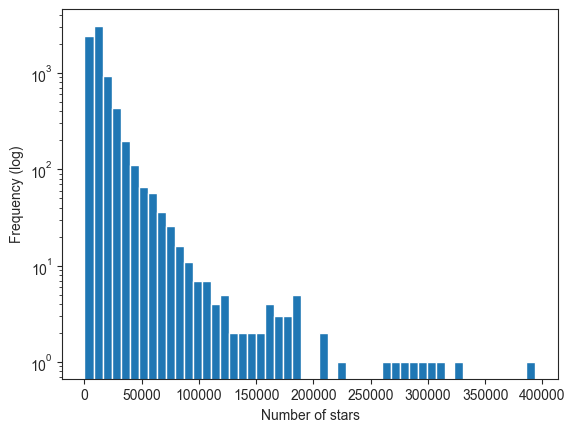

In [13]:
df["stargazers_count"].plot.hist(bins=50, logy=True, xlabel="Number of stars", ylabel="Frequency (log)")

In [14]:
display(df[df["stargazers_count"] > 10_000].shape[0])
display(df[df["stargazers_count"] > 50_000].shape[0])
display(df[df["stargazers_count"] > 100_000].shape[0])

3675

240

53

In [15]:
df.sort_values(by="stargazers_count", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
28457823,freeCodeCamp,freeCodeCamp,https://github.com/freeCodeCamp/freeCodeCamp,449544,main,BSD-3-Clause,TypeScript,"{'TypeScript': 2268093, 'JavaScript': 954807, ...",freeCodeCamp.org's open-source codebase and cu...,http://contribute.freecodecamp.org/intro,...,236,True,False,False,False,True,True,False,False,False
13491895,EbookFoundation,free-programming-books,https://github.com/EbookFoundation/free-progra...,18628,main,CC-BY-4.0,None,{},:books: Freely available programming books,https://ebookfoundation.github.io/free-program...,...,35,True,False,False,True,False,True,False,False,False
21737465,sindresorhus,awesome,https://github.com/sindresorhus/awesome,1517,main,CC0-1.0,None,{},😎 Awesome lists about all kinds of interesting...,None,...,38,True,False,False,True,False,True,False,False,False
54346799,public-apis,public-apis,https://github.com/public-apis/public-apis,5010,master,MIT,Python,"{'Python': 40479, 'Shell': 1352}",A collective list of free APIs,https://APILayer.com/?utm_source=Github&utm_me...,...,289,True,False,False,False,False,True,False,False,False
60493101,jwasham,coding-interview-university,https://github.com/jwasham/coding-interview-un...,22281,main,CC-BY-SA-4.0,None,{},A complete computer science study plan to beco...,None,...,44,True,False,False,False,False,True,False,False,False


We see that slightly more than a half of all repositories in a list have less than 10.000 stars, while the remaining repositories range from around 10.000 to almost 400.000 stars.
Only around 50 repositories have more than 100.000 stars.
The most popular repository is `freeCodeCamp/freeCodeCamp` with over 390.000 stars, which leads the second repository by over 65.000 stars.

### Forks Distribution

In [16]:
df["forks_count"].describe()

count      7424.000000
mean       3420.494073
std        6276.489792
min          19.000000
25%        1323.750000
50%        2105.500000
75%        3489.250000
max      243459.000000
Name: forks_count, dtype: float64

<Axes: xlabel='Number of forks', ylabel='Frequency (log)'>

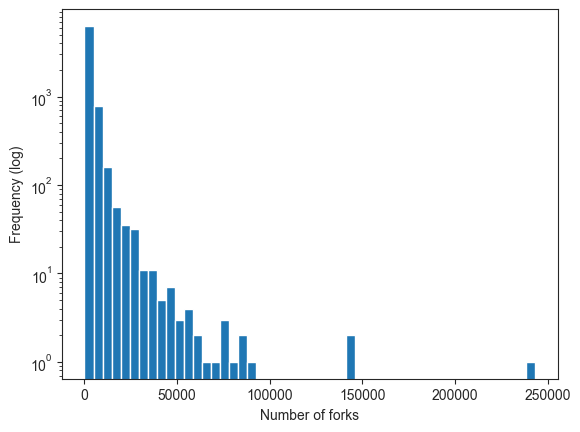

In [17]:
df["forks_count"].plot.hist(bins=50, logy=True, xlabel="Number of forks", ylabel="Frequency (log)")

In [18]:
display(df[df["forks_count"] > 10_000].shape[0])
display(df[df["forks_count"] > 50_000].shape[0])
display(df[df["forks_count"] > 100_000].shape[0])

319

21

3

In [19]:
df.sort_values(by="forks_count", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
14204342,jtleek,datasharing,https://github.com/jtleek/datasharing,590,master,None,None,{},The Leek group guide to data sharing,None,...,893,True,False,True,False,True,True,False,False,False
1300192,octocat,Spoon-Knife,https://github.com/octocat/Spoon-Knife,2,main,None,HTML,"{'HTML': 355, 'CSS': 256}",This repo is for demonstration purposes only.,None,...,17559,True,False,True,False,True,True,False,False,False
15917132,rdpeng,ProgrammingAssignment2,https://github.com/rdpeng/ProgrammingAssignment2,6670,master,None,R,{'R': 324},Repository for Programming Assignment 2 for R ...,None,...,4215,True,False,True,False,True,True,False,False,False
40212802,SmartThingsCommunity,SmartThingsPublic,https://github.com/SmartThingsCommunity/SmartT...,21066,master,None,Groovy,"{'Groovy': 5372198, 'Shell': 655}",SmartThings open-source DeviceType Handlers an...,https://developer-preview.smartthings.com/docs...,...,2512,True,False,True,False,True,True,False,False,False
121291758,Pierian-Data,Complete-Python-3-Bootcamp,https://github.com/Pierian-Data/Complete-Pytho...,37125,master,None,Jupyter Notebook,"{'Jupyter Notebook': 35097216, 'Python': 1767}",Course Files for Complete Python 3 Bootcamp Co...,None,...,226,True,False,True,False,True,True,False,False,False


More than 75% of the repositories have less than 3500 forks.
The remaining repositories have up to more than 240.000 forks.
We can see that less than 320 repositories have more than 10.000 forks, and only 3 repositories have more than 100.000 forks.
The most forked repository is `jtleek/datasharing` with more than 240.000 forks.
Interestingly, this is more than `octocat/Spoon-Knife`, an official repository meant to provide an example for forking a repository, which has around 100.000 forks less.

### Watchers Distributions

In [20]:
df["watchers_count"].describe()

count    7424.000000
mean      344.113012
std       547.307416
min         0.000000
25%        85.000000
50%       211.000000
75%       402.000000
max      9755.000000
Name: watchers_count, dtype: float64

<Axes: xlabel='Number of watchers', ylabel='Frequency (log)'>

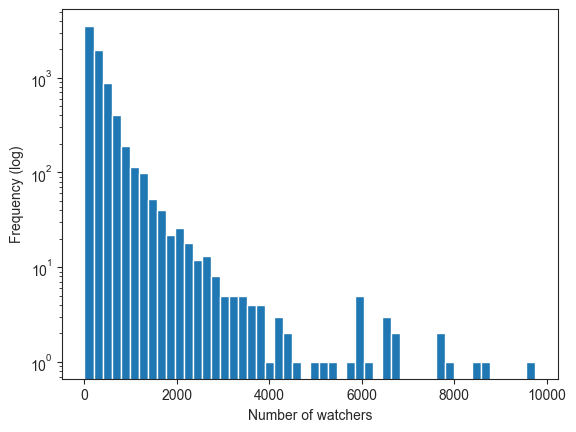

In [21]:
df["watchers_count"].plot.hist(bins=50, logy=True, xlabel="Number of watchers", ylabel="Frequency (log)")

In [22]:
display(df[df["watchers_count"] > 500].shape[0])
display(df[df["watchers_count"] > 1000].shape[0])
display(df[df["watchers_count"] > 5000].shape[0])

1370

431

21

In [23]:
df.sort_values(by="watchers_count", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
13491895,EbookFoundation,free-programming-books,https://github.com/EbookFoundation/free-progra...,18628,main,CC-BY-4.0,None,{},:books: Freely available programming books,https://ebookfoundation.github.io/free-program...,...,35,True,False,False,True,False,True,False,False,False
60493101,jwasham,coding-interview-university,https://github.com/jwasham/coding-interview-un...,22281,main,CC-BY-SA-4.0,None,{},A complete computer science study plan to beco...,None,...,44,True,False,False,False,False,True,False,False,False
28457823,freeCodeCamp,freeCodeCamp,https://github.com/freeCodeCamp/freeCodeCamp,449544,main,BSD-3-Clause,TypeScript,"{'TypeScript': 2268093, 'JavaScript': 954807, ...",freeCodeCamp.org's open-source codebase and cu...,http://contribute.freecodecamp.org/intro,...,236,True,False,False,False,True,True,False,False,False
2325298,torvalds,linux,https://github.com/torvalds/linux,5114330,master,NOASSERTION,C,"{'C': 1282300335, 'Assembly': 9568460, 'Shell'...",Linux kernel source tree,None,...,366,False,False,False,False,True,True,False,False,False
21737465,sindresorhus,awesome,https://github.com/sindresorhus/awesome,1517,main,CC0-1.0,None,{},😎 Awesome lists about all kinds of interesting...,None,...,38,True,False,False,True,False,True,False,False,False


Similar to the distribution of stars and forks, 75% of the repositories have less than around 400 watchers, while the remaining 25% of repositories have from 400 to almost 10.000 watchers.
However, it should be noted that the source data were not explicitly collected based on the number of watchers, and the results here are based only on top repositories by the other two metrics.

## Other Numerical Properties

We can analyze a few other interesting numerical properties of repositories.

### Number of Open Issues and Pull Requests

In [24]:
df["open_issues_count"].describe()

count     7424.000000
mean       345.040140
std       1032.803631
min          0.000000
25%         18.000000
50%         84.000000
75%        289.250000
max      29506.000000
Name: open_issues_count, dtype: float64

<Axes: xlabel='Number of open issues and PRs', ylabel='Frequency (log)'>

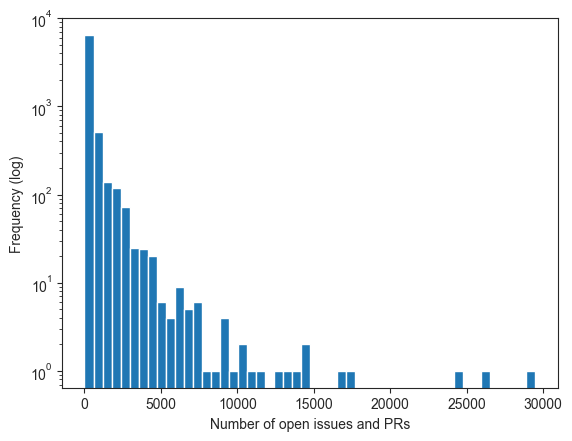

In [25]:
df["open_issues_count"].plot.hist(bins=50, logy=True, xlabel="Number of open issues and PRs", ylabel="Frequency (log)")

In [26]:
display(df[df["open_issues_count"] > 100].shape[0])
display(df[df["open_issues_count"] > 500].shape[0])
display(df[df["open_issues_count"] > 1000].shape[0])
display(df[df["open_issues_count"] > 5000].shape[0])

3458

1134

535

48

In [27]:
df.sort_values(by="open_issues_count", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
281975310,type-challenges,type-challenges,https://github.com/type-challenges/type-challe...,2836,main,MIT,TypeScript,"{'TypeScript': 173759, 'HTML': 2046, 'CSS': 96...",Collection of TypeScript type challenges with ...,https://tsch.js.org/,...,29506,True,True,False,False,True,True,False,False,False
228683419,google,it-cert-automation-practice,https://github.com/google/it-cert-automation-p...,16,master,Apache-2.0,Python,{'Python': 2407},Google IT Automation with Python Professional ...,None,...,26506,True,False,True,False,True,True,False,False,False
75821432,llvm,llvm-project,https://github.com/llvm/llvm-project,1523608,main,NOASSERTION,LLVM,"{'LLVM': 496184046, 'C++': 444876991, 'C': 228...",The LLVM Project is a collection of modular an...,http://llvm.org,...,24631,True,False,False,False,False,True,False,False,False
1300192,octocat,Spoon-Knife,https://github.com/octocat/Spoon-Knife,2,main,None,HTML,"{'HTML': 355, 'CSS': 256}",This repo is for demonstration purposes only.,None,...,17559,True,False,True,False,True,True,False,False,False
177736533,996icu,996.ICU,https://github.com/996icu/996.ICU,187804,master,NOASSERTION,None,{},Repo for counting stars and contributing. Pres...,https://996.icu,...,16707,False,False,False,False,False,True,False,False,False


We see a similar distribution of open issues and PRs as with previous repository properties.
More than a half of repositories have less than 100 open issues and PRs, and only less than 600 repositories have more than 1000 issues and PRs open.
The repository with the most opened issues is `type-challenges/type-challenges`, where the issues are answers for programming challenges.

### Number of Topics

In [28]:
df["topics"].map(len).describe()

count    7424.000000
mean        5.385102
std         5.701214
min         0.000000
25%         0.000000
50%         4.000000
75%         8.000000
max        20.000000
Name: topics, dtype: float64

In [29]:
df[(df["topics"].map(len) > 0) & (df["topics"].map(len) < 20)]["topics"].map(len).describe()

count    4592.000000
mean        7.630444
std         4.437515
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        19.000000
Name: topics, dtype: float64

<Axes: xlabel='Number of topics', ylabel='Frequency (log)'>

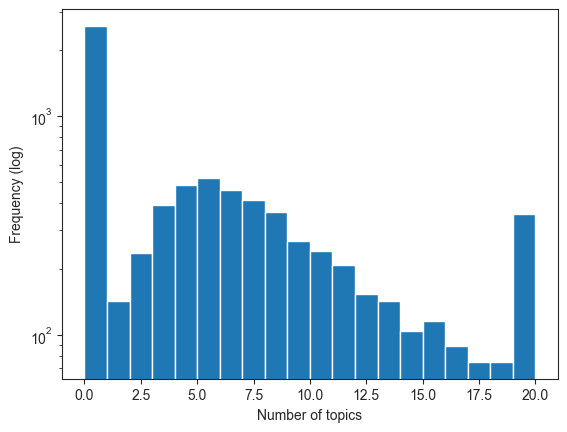

In [30]:
df["topics"].map(len).plot.hist(bins=20, logy=True, xlabel="Number of topics", ylabel="Frequency (log)")

In [31]:
display(df[df["topics"].map(len) == 0].shape[0])
display(df[(df["topics"].map(len) > 0) & (df["topics"].map(len) < 20)].shape[0])
display(df[df["topics"].map(len) == 20].shape[0])

2585

4592

247

In [32]:
df.sort_values(by="topics", key=lambda col: col.str.len(), ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,open_issues_count,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived
id,,,,,,,,,,,,,,,,,,,,,
93438176,ZoranPandovski,al-go-rithms,https://github.com/ZoranPandovski/al-go-rithms,57563,master,CC0-1.0,Jupyter Notebook,"{'Jupyter Notebook': 21909905, 'C++': 1692994,...",:musical_note: Algorithms written in different...,None,...,64,True,True,True,True,True,True,False,False,False
91253698,ccxt,ccxt,https://github.com/ccxt/ccxt,3247301,master,MIT,Python,"{'Python': 28162915, 'C#': 26223722, 'TypeScri...",A JavaScript / TypeScript / Python / C# / PHP ...,https://docs.ccxt.com,...,1227,True,False,True,True,True,True,False,False,False
144152935,trimstray,test-your-sysadmin-skills,https://github.com/trimstray/test-your-sysadmi...,1312,master,MIT,None,{},A collection of Linux Sysadmin Test Questions ...,None,...,17,True,False,False,False,False,True,False,False,False
43425480,wilsonfreitas,awesome-quant,https://github.com/wilsonfreitas/awesome-quant,2141,master,None,Python,"{'Python': 6806, 'CSS': 17}","A curated list of insanely awesome libraries, ...",https://wilsonfreitas.github.io/awesome-quant/,...,13,True,False,True,True,True,True,False,False,False
43441403,strapi,strapi,https://github.com/strapi/strapi,507472,develop,NOASSERTION,TypeScript,"{'TypeScript': 7400380, 'JavaScript': 2459149,...",🚀 Strapi is the leading open-source headless C...,https://strapi.io,...,733,True,False,False,False,True,True,False,False,False


The distribution of the number of topics is quite different from the previous distributions.
There are a lot of repositories without any topics, and many repositories with 20 topics, which is the maximum number of topics a repository can have.
Excluding these two outliers, most repositories have between 4 and 10 topics.

### Size & Lines of Code

In [33]:
df["lines"] = df["languages"].apply(pd.Series).sum(axis=1).astype(int)

In [34]:
df[["size", "lines"]].describe()

,size,lines
count,7.424000e+03,7.424000e+03
mean,2.064338e+05,7.559004e+06
std,1.794956e+06,5.003956e+07
min,0.000000e+00,0.000000e+00
25%,1.658750e+03,2.689650e+04
50%,1.318450e+04,3.901455e+05
75%,7.591225e+04,2.529126e+06
max,1.006752e+08,1.346571e+09


In [35]:
df.sort_values(by="size", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived,lines
id,,,,,,,,,,,,,,,,,,,,,
246079929,owid,covid-19-data,https://github.com/owid/covid-19-data,100675175,master,None,Python,"{'Python': 1501762, 'HTML': 445156, 'Jupyter N...","Data on COVID-19 (coronavirus) cases, deaths, ...",https://ourworldindata.org/coronavirus,...,True,True,False,False,False,True,False,False,False,2025753
1409811,cdnjs,cdnjs,https://github.com/cdnjs/cdnjs,52604791,master,MIT,None,{},🤖 CDN assets - The #1 free and open source CDN...,https://cdnjs.com,...,True,True,False,False,False,True,False,False,False,0
120360765,chromium,chromium,https://github.com/chromium/chromium,47152920,main,BSD-3-Clause,None,{},The official GitHub mirror of the Chromium source,https://chromium.googlesource.com/chromium/src/,...,False,False,False,False,False,True,False,False,False,0
3565909,raspberrypi,firmware,https://github.com/raspberrypi/firmware,39892092,master,None,None,{},This repository contains pre-compiled binaries...,None,...,True,False,True,False,True,True,False,False,False,0
189256120,vernesong,OpenClash,https://github.com/vernesong/OpenClash,39845406,master,MIT,JavaScript,"{'JavaScript': 600544, 'Shell': 569815, 'Lua':...",A Clash Client For OpenWrt,None,...,True,True,True,False,False,True,False,False,False,1812346


In [36]:
df.sort_values(by="lines", ascending=False).head()

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived,lines
id,,,,,,,,,,,,,,,,,,,,,
75821432,llvm,llvm-project,https://github.com/llvm/llvm-project,1523608,main,NOASSERTION,LLVM,"{'LLVM': 496184046, 'C++': 444876991, 'C': 228...",The LLVM Project is a collection of modular an...,http://llvm.org,...,True,False,False,False,False,True,False,False,False,1346570654
23891194,Azure,azure-powershell,https://github.com/Azure/azure-powershell,2097965,main,NOASSERTION,C#,"{'C#': 1202516016, 'PowerShell': 139034925, 'B...",Microsoft Azure PowerShell,None,...,True,True,True,False,True,True,False,False,False,1341576646
2325298,torvalds,linux,https://github.com/torvalds/linux,5114330,master,NOASSERTION,C,"{'C': 1282300335, 'Assembly': 9568460, 'Shell'...",Linux kernel source tree,None,...,False,False,False,False,True,True,False,False,False,1304444078
7408108,RT-Thread,rt-thread,https://github.com/RT-Thread/rt-thread,866908,master,Apache-2.0,C,"{'C': 1234433878, 'Assembly': 23622214, 'HTML'...",RT-Thread is an open source IoT real-time oper...,https://www.rt-thread.io,...,True,True,True,False,True,True,False,False,False,1267667855
3199002,raspberrypi,linux,https://github.com/raspberrypi/linux,4098537,rpi-6.6.y,NOASSERTION,C,"{'C': 1222768149, 'Assembly': 9830805, 'Shell'...",Kernel source tree for Raspberry Pi-provided k...,None,...,True,False,True,False,False,True,False,False,False,1244854671


Note that neither of these two metrics is completely reliable.
The repository size may not be accurate because of how GitHub stores repositories and deduplicates objects to achieve lower storage cost.
The number of lines is also not always accurate, as GitHub sometimes fails to detect the languages of a repository.
For example, this happens on some large repositories such as cdnjs, Chromium and Firefox, which causes the number of lines to be zero.

## Boolean Properties

We will analyze a few interesting boolean properties about repositories.

In [37]:
def number_of_with_without(series: pd.Series) -> (int, int):
    """Returns the number of rows that do and do not match the boolean series."""
    return df[series].shape[0], df[~series].shape[0]

### Social Properties

In [38]:
# Number of repositories with/without description
number_of_with_without(~df["description"].isnull())

(6755, 669)

In [39]:
# Number of repositories with/without homepage
number_of_with_without(~df["homepage"].isnull())

(4251, 3173)

In [40]:
# Number of repositories with/without topics
number_of_with_without(df["topics"].map(len) != 0)

(4839, 2585)

In [41]:
# Number of repositories with/without license
number_of_with_without(~df["license"].isnull())

(6031, 1393)

Most of the popular repositories follow commonly-recommended best practices of setting the repository description, homepage, topics and licenses.
Almost all the repositories have the description set, while the amount of repositories with the homepage or topics set is smaller, but still more than a half.

### Features Properties

In [42]:
# Number of repositories with issues enabled
number_of_with_without(df["has_issues"])

(6961, 463)

In [43]:
# Number of repositories with discussions enabled
number_of_with_without(df["has_discussions"])

(2264, 5160)

In [44]:
# Number of repositories with wiki enabled
number_of_with_without(df["has_wiki"])

(4942, 2482)

In [45]:
# Number of repositories with pages enabled
number_of_with_without(df["has_pages"])

(1817, 5607)

In [46]:
# Number of repositories with projects enabled
number_of_with_without(df["has_projects"])

(5796, 1628)

In [47]:
# Number of repositories with downloads enabled
number_of_with_without(df["has_downloads"])

(7307, 117)

Almost all the repositories have issues enabled, while most of the repositories do not have discussions enabled, as they are a recently added feature.
Additionally, most the the repositories have wiki and projects enabled, but most do not have GitHub Pages enabled.
Downloads are a legacy feature that does not exist since 2013, and only repositories with it disabled are the ones that disabled it before it was removed.

## Date Properties

For each repository we know the dates when the repository was created, last updated and last pushed to. 

### Created Date

The created date contains the date and time when the repository was created.

In [48]:
df["created_at"].describe()

count                                   7424
mean     2017-01-16 07:02:33.973464576+00:00
min                2008-03-10 07:34:08+00:00
25%                2014-07-14 12:06:24+00:00
50%                2016-12-20 07:36:16+00:00
75%      2019-09-02 11:02:30.750000128+00:00
max                2024-07-08 11:32:35+00:00
Name: created_at, dtype: object

In [49]:
df.sort_values(by="created_at")

,owner,name,url,size,default_branch,license,language,languages,description,homepage,...,has_issues,has_discussions,has_wiki,has_pages,has_projects,has_downloads,is_fork,is_template,is_archived,lines
id,,,,,,,,,,,,,,,,,,,,,
3282,preservim,nerdtree,https://github.com/preservim/nerdtree,1995,master,WTFPL,Vim Script,{'Vim Script': 217175},A tree explorer plugin for vim.,None,...,True,False,True,False,False,True,False,False,False,217175
3314,spree,spree,https://github.com/spree/spree,155135,main,BSD-3-Clause,Ruby,"{'Ruby': 3046097, 'HTML': 26893, 'Shell': 4764...",An open source eCommerce platform giving you f...,https://spreecommerce.org,...,True,True,False,False,True,True,False,False,False,3077778
8393,thoughtbot,paperclip,https://github.com/thoughtbot/paperclip,3579,main,NOASSERTION,Ruby,"{'Ruby': 522650, 'Gherkin': 8317, 'HTML': 407}",Easy file attachment management for ActiveRecord,https://thoughtbot.com,...,True,False,True,False,False,True,False,False,True,531374
8514,rails,rails,https://github.com/rails/rails,280094,main,MIT,Ruby,"{'Ruby': 16757609, 'JavaScript': 216319, 'HTML...",Ruby on Rails,https://rubyonrails.org,...,True,True,False,False,True,True,False,False,False,17151472
15435,Shopify,liquid,https://github.com/Shopify/liquid,5705,main,MIT,Ruby,"{'Ruby': 467586, 'Liquid': 72882}","Liquid markup language. Safe, customer facing ...",https://shopify.github.io/liquid/,...,True,False,True,True,True,True,False,False,False,540468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808045485,LadybirdBrowser,ladybird,https://github.com/LadybirdBrowser/ladybird,226351,master,BSD-2-Clause,C++,"{'C++': 24568535, 'JavaScript': 2309458, 'HTML...",Truly independent web browser,https://ladybird.org,...,True,False,False,False,False,True,False,False,False,28971785
812323913,tech-shrimp,docker_image_pusher,https://github.com/tech-shrimp/docker_image_pu...,734,main,Apache-2.0,None,{},使用Github Action将国外的Docker镜像转存到阿里云私有仓库，供国内服务器使用...,None,...,True,False,True,False,True,True,False,False,False,0
813254316,cmliu,CF-Workers-docker.io,https://github.com/cmliu/CF-Workers-docker.io,25,main,None,JavaScript,{'JavaScript': 9865},这个项目是一个基于 Cloudflare Workers 的 Docker 镜像代理工具。它...,https://docker.fxxk.dedyn.io,...,True,False,False,False,True,True,False,False,False,9865


<Axes: xlabel='Year created', ylabel='Frequency'>

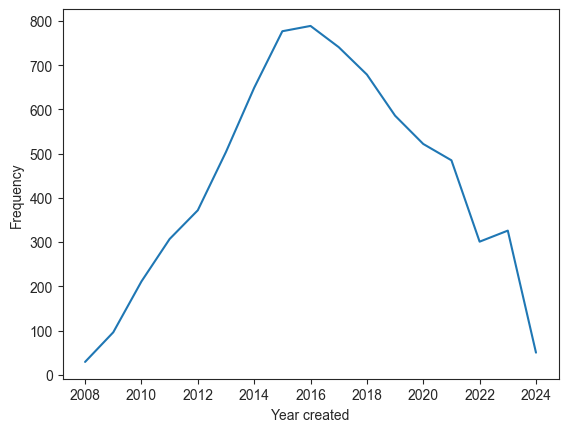

In [50]:
df.groupby(df["created_at"].dt.year).size().plot(xlabel="Year created", ylabel="Frequency")

The oldest repository in our list, `preservim/nerdtree`, has been created in March 2008, only around a month after GitHub was created.
The newest repository in the list, `ShiArthur03/ShiArthur03`, has been created in July 2024, less than a week ago at the time of writing.

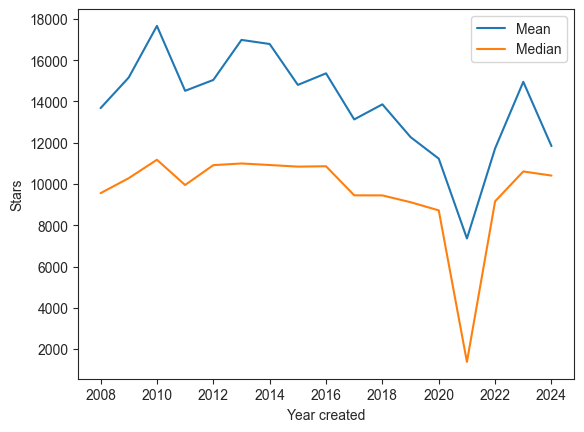

In [51]:
ax = df.groupby(df["created_at"].dt.year).agg({"stargazers_count": ("mean", "median")}).plot()
ax.set_xlabel("Year created")
ax.set_ylabel("Stars")
ax.legend(["Mean", "Median"])

The median number of stars per creation year seems to be roughly the same, although older repositories are slightly more popular.
However, there a large drop of popular repositories created in 2021.
The same drop can also be seen in the mean number of stars, with a small spike of popular repositories created in 2023.
Based on the mean number of stars, older repositories are generally more popular.

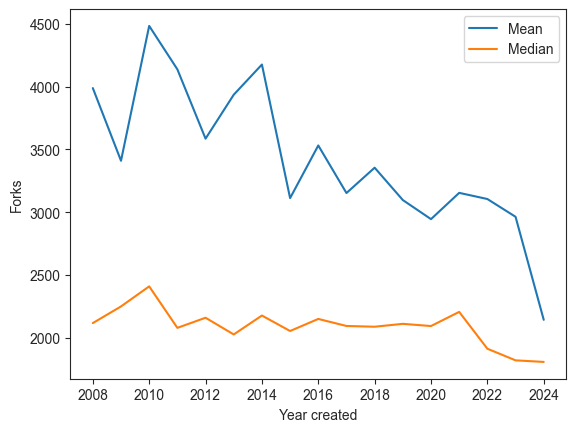

In [52]:
ax = df.groupby(df["created_at"].dt.year).agg({"forks_count": ("mean", "median")}).plot()
ax.set_xlabel("Year created")
ax.set_ylabel("Forks")
ax.legend(["Mean", "Median"])

Similar as for stars, older repositories have more forks, both according to the median and mean.
There are no unusual large spikes or drops.

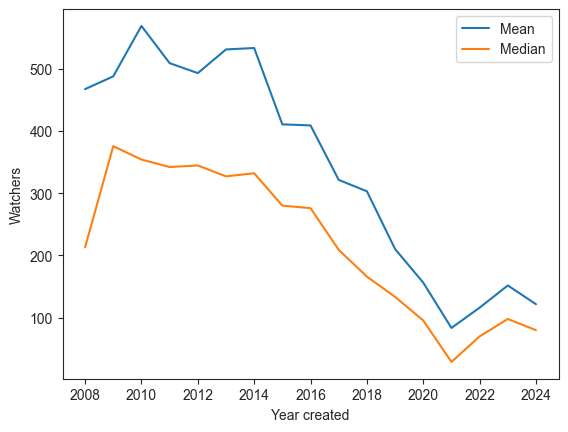

In [53]:
ax = df.groupby(df["created_at"].dt.year).agg({"watchers_count": ("mean", "median")}).plot()
ax.set_xlabel("Year created")
ax.set_ylabel("Watchers")
ax.legend(["Mean", "Median"])

The number of watchers per creation year also has a similar pattern, with the same drop in 2021 as for stars.

### Updated Date

The updated date represents the date and time when the repository object was last updated.
The exact events that are considered updates are not known, but they include changing the repository description, homepage and topics, adding or editing wiki pages, starring a repository, etc.
Note that it is not necessary that a push affects the updated date; that will only happen if it triggers an update to the repository object, like changing the primary repository language.

In [54]:
df["updated_at"].describe()

count                                   7424
mean     2024-06-10 12:59:36.343345664+00:00
min                2017-04-26 23:13:47+00:00
25%         2024-07-12 08:41:35.500000+00:00
50%                2024-07-13 13:17:19+00:00
75%         2024-07-13 18:44:45.500000+00:00
max                2024-07-14 00:30:28+00:00
Name: updated_at, dtype: object

<Axes: xlabel='Year last updated', ylabel='Frequency'>

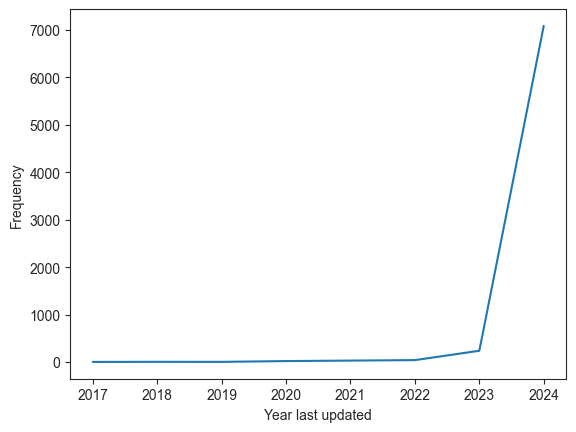

In [55]:
df.groupby(df["updated_at"].dt.year).size().plot(xlabel="Year last updated", ylabel="Frequency")

In [56]:
display(df[df["updated_at"] < pd.Timestamp("2024-01-01", tz="UTC")].shape[0])
display(df[df["updated_at"] < pd.Timestamp("2024-06-01", tz="UTC")].shape[0])

343

601

In [57]:
display(df[df["updated_at"] >= pd.Timestamp("2024-07-07", tz="UTC")].shape[0])

6487

Almost all the repositories have been updated in the last week (between 2024-07-07 and 2024-07-14).
This effectively means that almost all the repositories have received at least one star in that week.
Less than 350 repositories have not been updated yet in 2024.

### Pushed Date

The pushed date is updated any time a commit is pushed to any of the repository’s branches.

In [58]:
df["pushed_at"].describe()

count                                   7424
mean     2023-12-26 08:37:08.788658432+00:00
min                2010-11-16 21:55:39+00:00
25%      2024-02-16 16:43:54.750000128+00:00
50%                2024-06-29 14:50:05+00:00
75%         2024-07-12 14:18:24.500000+00:00
max                2024-07-14 00:28:29+00:00
Name: pushed_at, dtype: object

<Axes: xlabel='Year last pushed', ylabel='Frequency'>

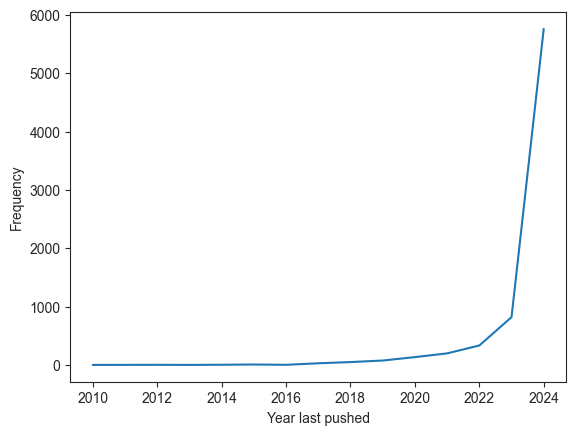

In [59]:
df.groupby(df["pushed_at"].dt.year).size().plot(xlabel="Year last pushed", ylabel="Frequency")

In [60]:
display(df[df["pushed_at"] < pd.Timestamp("2024-01-01", tz="UTC")].shape[0])
display(df[df["pushed_at"] < pd.Timestamp("2024-06-01", tz="UTC")].shape[0])

1663

2851

In [61]:
display(df[df["pushed_at"] >= pd.Timestamp("2024-07-07", tz="UTC")].shape[0])

3193

We can see that most of the repositories have been pushed to in recent months.
However, the pushed dates are generally older than the updated dates.

## Languages

Our data contain both the primary (most used) language, and a list of all languages and their corresponding lines of code, for each repository.

In [62]:
language_info = df["languages"].apply(pd.Series)
languages_by_repositories = language_info.count().astype(int).to_frame(name="repositories")
languages_by_shares = language_info.div(df["lines"], axis=0).sum().astype(float).to_frame(name="shares")
languages_by_lines = language_info.sum().astype(int).to_frame(name="lines")
languages = pd.concat([languages_by_repositories, languages_by_shares, languages_by_lines], axis=1)
languages.index.rename("language", inplace=True)

### Main Language

First, we will analyze the most popular primary languages of our repositories.

In [63]:
df["language"].describe()

count           6705
unique           113
top       JavaScript
freq            1372
Name: language, dtype: object

In [64]:
df["language"].value_counts()

language
JavaScript    1372
Python         941
TypeScript     634
Java           543
Go             460
              ... 
HLSL             1
PostScript       1
Solidity         1
Mojo             1
Logos            1
Name: count, Length: 113, dtype: int64

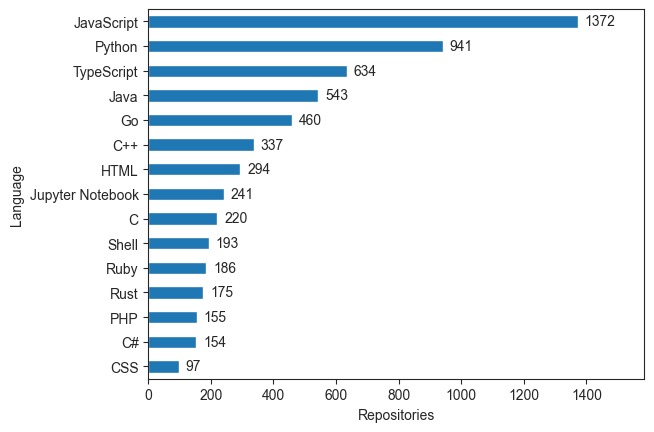

In [65]:
ax = df["language"].value_counts().nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Language")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

We can see that the most popular main language is JavaScript, followed by Python and TypeScript.

### All Languages by Repositories

We can also analyze all languages used by each repository, measured by the number of repositories for each language.

In [66]:
languages.sort_values(by="repositories", ascending=False)

,repositories,shares,lines
language,,,
JavaScript,3535,1303.899580,2487440928
Shell,3319,213.001402,358015555
HTML,3008,382.196074,2168905897
Python,2316,908.591148,4607446374
CSS,2241,158.549579,313007570
...,...,...,...
Nearley,1,0.000799,9654
Befunge,1,0.000015,173
AL,1,0.000009,102


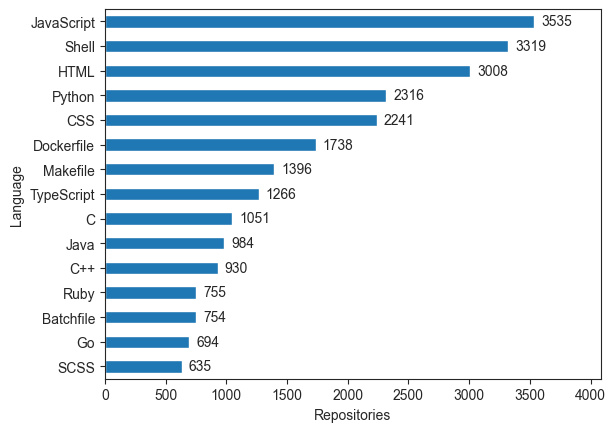

In [67]:
ax = languages["repositories"].nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Language")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

Here, JavaScript is still in the lead, however, Python is only in the fourth place, behind Shell and HTML.
This is likely because a lot of repositories use Shell scripts for various utilities.
Similarly, Dockerfile and Makefile are also in the top 10 languages.

In [68]:
# Languages included in the top 15 in both lists
set(df["language"].value_counts().nlargest(15).index) & set(languages["repositories"].nlargest(15).index)

{'C',
 'C++',
 'CSS',
 'Go',
 'HTML',
 'Java',
 'JavaScript',
 'Python',
 'Ruby',
 'Shell',
 'TypeScript'}

In [69]:
# Languages included in the top 15 only in the main language list
set(df["language"].value_counts().nlargest(15).index) - set(languages["repositories"].nlargest(15).index)

{'C#', 'Jupyter Notebook', 'PHP', 'Rust'}

In [70]:
# Languages included in the top 15 only in the all languages list
set(languages["repositories"].nlargest(15).index) - set(df["language"].value_counts().nlargest(15).index)

{'Batchfile', 'Dockerfile', 'Makefile', 'SCSS'}

We can see that most top 15 languages are included in both lists.

### All Languages by Lines of Code

We can also analyze all languages used by each repository, measured by lines of code for each language.

In [71]:
languages.sort_values(by="lines", ascending=False)

,repositories,shares,lines
language,,,
C,1051,2.174670e+02,10321882570
Java,984,4.988207e+02,7679202159
C++,930,3.000191e+02,6627523428
Jupyter Notebook,440,2.325691e+02,5142243167
Python,2316,9.085911e+02,4607446374
...,...,...,...
Opa,1,3.388624e-04,20
Shen,1,3.219193e-04,19
Motoko,1,6.145334e-07,16


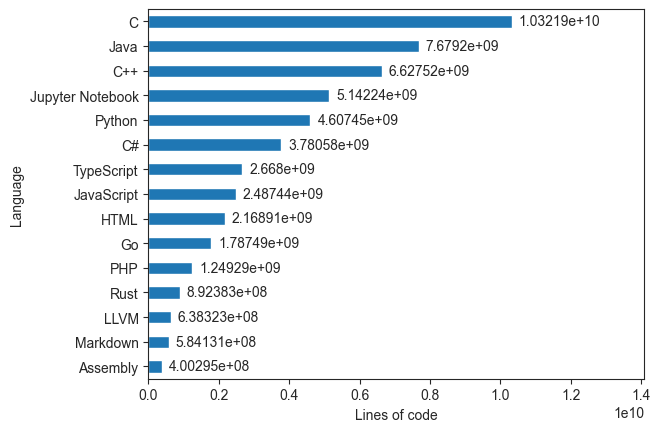

In [72]:
ax = languages["lines"].nlargest(15).plot.barh()
ax.set_xlabel("Lines of code")
ax.set_ylabel("Language")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.3)
ax.invert_yaxis()

The top languages by the lines of code are quite different from the previous lists.
Languages like C, C++ and Java are in the lead, probably because they are used by many large projects such as Linux, Android and LLVM.
Jupyter Notebook has an unrealistically large number of lines of code, as it is stored in complex and long JSON files.
Python is only in the 5th place, while JavaScript and TypeScript are even lower.

### All Languages by Shares

For a possibly more meaningful comparison, we can compare languages by their shares in each repository.

In [73]:
languages.sort_values(by="shares", ascending=False)

,repositories,shares,lines
language,,,
JavaScript,3535,1.303900e+03,2487440928
Python,2316,9.085911e+02,4607446374
TypeScript,1266,5.845524e+02,2668002949
Java,984,4.988207e+02,7679202159
Go,694,4.234658e+02,1787488684
...,...,...,...
RouterOS Script,2,2.887938e-06,82
Motoko,1,6.145334e-07,16
Nextflow,1,8.904823e-08,79


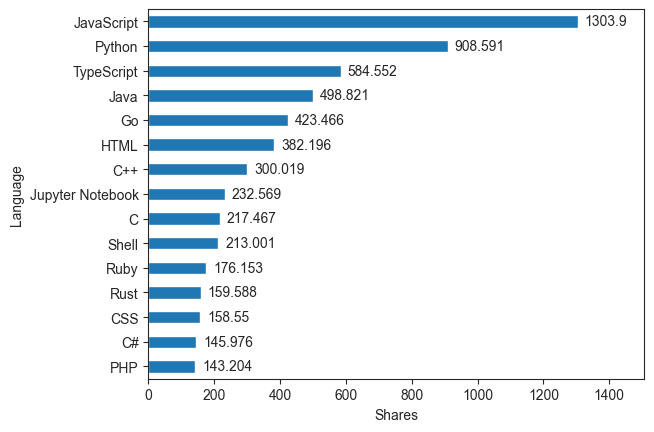

In [74]:
ax = languages["shares"].nlargest(15).plot.barh()
ax.set_xlabel("Shares")
ax.set_ylabel("Language")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

The distribution here is very similar to the distribution of the top 15 min repository languages.
This is likely because many repositories mostly use only one primary language.

In [75]:
# Languages included in the top 15 in both lists
set(df["language"].value_counts().nlargest(15).index) & set(languages["shares"].nlargest(15).index)

{'C',
 'C#',
 'C++',
 'CSS',
 'Go',
 'HTML',
 'Java',
 'JavaScript',
 'Jupyter Notebook',
 'PHP',
 'Python',
 'Ruby',
 'Rust',
 'Shell',
 'TypeScript'}

The top 15 languages in both lists are exactly the same, only with some minor variations in their order.

### Stars by Main Language

We can check how popular each language is in terms of stars.

In [76]:
df.groupby("language")["stargazers_count"].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
ANTLR,1.0,9977.000000,NaN,9977.0,9977.00,9977.0,9977.00,9977.0
ApacheConf,1.0,396.000000,NaN,396.0,396.00,396.0,396.00,396.0
Apex,1.0,100.000000,NaN,100.0,100.00,100.0,100.00,100.0
Arduino,1.0,97.000000,NaN,97.0,97.00,97.0,97.00,97.0
Assembly,9.0,16120.888889,17739.398851,10.0,9917.00,10388.0,15401.00,57116.0
...,...,...,...,...,...,...,...,...
Vue,46.0,15455.847826,14620.829033,1175.0,8646.75,10725.5,17342.75,87101.0
WebAssembly,1.0,16601.000000,NaN,16601.0,16601.00,16601.0,16601.00,16601.0
Wikitext,1.0,9129.000000,NaN,9129.0,9129.00,9129.0,9129.00,9129.0


In [77]:
stars_for_languages = df.groupby("language")["stargazers_count"].agg(total="sum", average="mean", repositories="count")

First, we can calculate the total number of stars for each language.

In [78]:
stars_for_languages.sort_values(by="total", ascending=False)

,total,average,repositories
language,,,
JavaScript,16161416,11779.457726,1372
Python,15389570,16354.484591,941
TypeScript,12193379,19232.458991,634
Go,7570527,16457.667391,460
Java,6357920,11708.876611,543
...,...,...,...
Logos,857,857.000000,1
ApacheConf,396,396.000000,1
Apex,100,100.000000,1


This obviously favors the most used languages.

Alternatively, we can also rate languages based on the average number of stars.

In [79]:
stars_for_languages.sort_values(by="average", ascending=False)

,total,average,repositories
language,,,
Nunjucks,59272,59272.0,1
Julia,45018,45018.0,1
Zig,113145,37715.0,3
V,35547,35547.0,1
Astro,57941,28970.5,2
...,...,...,...
Logos,857,857.0,1
ApacheConf,396,396.0,1
Apex,100,100.0,1


The results here are quite different and unexpected.
We can see that this favors languages with very few repositories.

For a better understanding, we can analyze the average number of stars only for commonly used languages.

In [80]:
stars_for_languages.nlargest(15, "repositories").sort_values(by="average", ascending=False)

,total,average,repositories
language,,,
TypeScript,12193379,19232.458991,634
Rust,3295595,18831.971429,175
Go,7570527,16457.667391,460
Python,15389570,16354.484591,941
C++,5407414,16045.738872,337
C,3115040,14159.272727,220
Shell,2466508,12779.834197,193
C#,1839139,11942.461039,154
JavaScript,16161416,11779.457726,1372


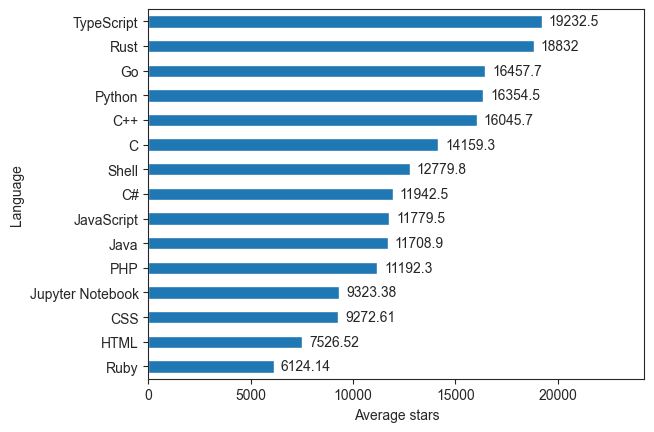

In [81]:
ax = stars_for_languages.nlargest(15, "repositories").sort_values(by="average", ascending=False)["average"].plot.barh()
ax.set_xlabel("Average stars")
ax.set_ylabel("Language")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.2)
ax.invert_yaxis()

In this case, we can see that TypeScript, Rust and Go repositories are the most popular.
Slightly surprisingly, JavaScript is only in the second half of the list.

## Licenses

We will analyze the most used repository licenses.

In [82]:
df["license"].describe()

count     6031
unique      31
top        MIT
freq      2383
Name: license, dtype: object

In [83]:
df["license"].value_counts()

license
MIT                   2383
NOASSERTION           1217
Apache-2.0            1186
GPL-3.0                428
BSD-3-Clause           164
AGPL-3.0               153
GPL-2.0                 89
CC0-1.0                 88
CC-BY-4.0               51
BSD-2-Clause            49
MPL-2.0                 43
CC-BY-SA-4.0            32
Unlicense               29
LGPL-2.1                26
LGPL-3.0                24
ISC                     14
OFL-1.1                 12
WTFPL                   10
Zlib                     8
MIT-0                    4
OSL-3.0                  3
EPL-2.0                  3
BSL-1.0                  3
Vim                      2
EPL-1.0                  2
Artistic-2.0             2
MS-PL                    2
LPPL-1.3c                1
UPL-1.0                  1
0BSD                     1
BSD-3-Clause-Clear       1
Name: count, dtype: int64

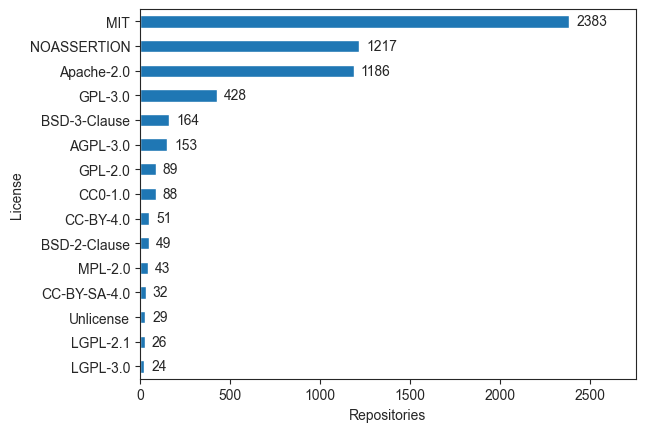

In [84]:
ax = df["license"].value_counts().nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("License")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

The MIT license is by far the most common, followed by Apache 2.0 with over 1000 repositories less.
Note that `NOASSERTION` means that the repository has a license set, but GitHub was unable to classify it, which may happen if the repository uses a custom license or multiple licenses.
We can see that this happens quite often and is the second most common "license type" of our repositories.

## Topics

We can analyze the topics of all popular repositories.

In [85]:
df["topics"].explode().describe()

count             39979
unique            12927
top       hacktoberfest
freq                609
Name: topics, dtype: object

In [86]:
df["topics"].explode().value_counts()

topics
hacktoberfest       609
javascript          585
python              514
react               296
machine-learning    246
                   ... 
file-management       1
activerecord          1
activejob             1
html-standard         1
spreecommerce         1
Name: count, Length: 12927, dtype: int64

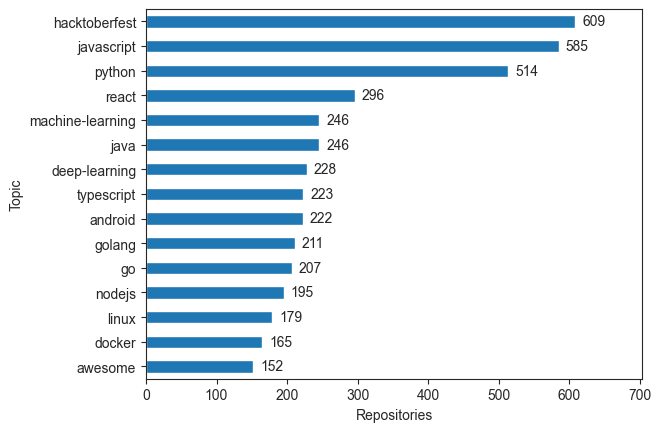

In [87]:
ax = df["topics"].explode().value_counts().nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Topic")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

The most popular topic is `hacktoberfest`, which indicates the repository participates in the Hacktoberfest event.
Topics for languages are also very popular, most common being `javascript`, `python` and `java`. 

In [88]:
# We exclude "technical" properties like `hacktoberfest` and common languages
all_topics = df["topics"].explode().value_counts()
excluded_topics = {"hacktoberfest", "javascript", "typescript", "python", "java", "kotlin", "rust", "go", "golang", "html", "css", "php", "ruby", "swift", "c", "cpp", "csharp"}
remaining_topics = all_topics[~all_topics.index.isin(excluded_topics)]

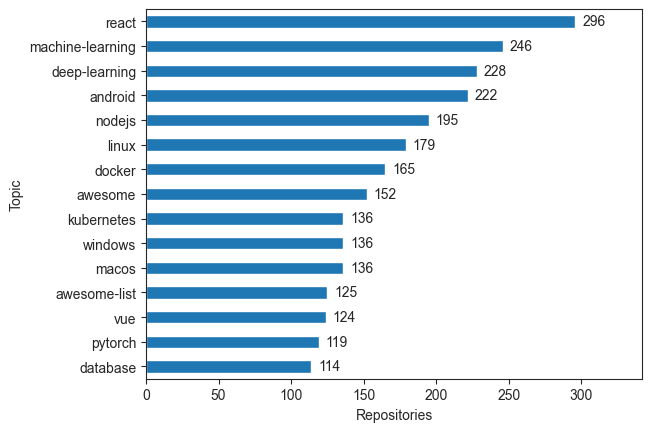

In [89]:
ax = remaining_topics.nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Topic")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

If we exclude `hacktoberfest` and topics for languages, we can see that the most popular topic is `react`, followed by `machine-learning` and `deep-learning`.

## Owners

We can check which users and organizations own most of the popular repositories.

In [90]:
df["owner"].describe()

count                    7424
unique                   5256
top       learn-co-curriculum
freq                      203
Name: owner, dtype: object

In [91]:
df["owner"].value_counts()

owner
learn-co-curriculum           203
microsoft                      84
learn-co-students              71
bloominstituteoftechnology     61
apache                         55
                             ... 
2noise                          1
LadybirdBrowser                 1
tech-shrimp                     1
wukongdaily                     1
rails                           1
Name: count, Length: 5256, dtype: int64

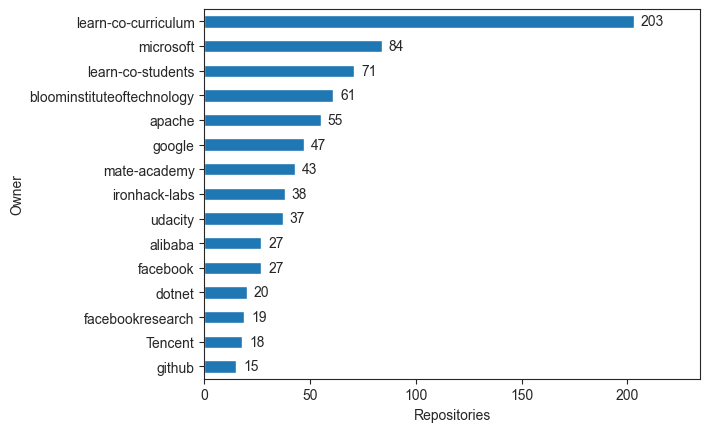

In [92]:
ax = df["owner"].value_counts().nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Owner")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

Most repositories are owned by many distinct users.
Account with by far the most of the popular repositories is `learn-co-curriculum`, which has more than 12.000 repositories, out of which, slightly more than 200 are included in our list.
Another popular account is `learn-co-students`, which seems to belong to the same organization, and has in total over 275.000 repositories.
Most other accounts on the list are, as expected, large companies and organizations. 

## Default Branches

The default branch is the one that shown and cloned by default. We will analyze what the most common default branch names for repositories on our list are.

In [93]:
df["default_branch"].describe()

count       7424
unique       188
top       master
freq        4656
Name: default_branch, dtype: object

In [94]:
df["default_branch"].value_counts()

default_branch
master        4656
main          2128
develop        159
dev            107
gh-pages        28
              ... 
oss              1
Master           1
flow             1
4.1-Stable       1
starter          1
Name: count, Length: 188, dtype: int64

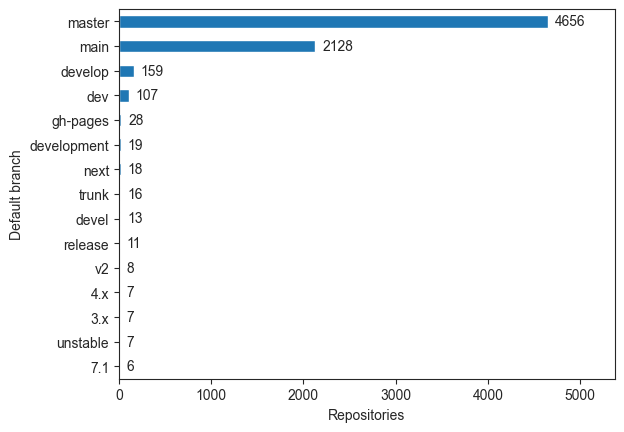

In [95]:
ax = df["default_branch"].value_counts().nlargest(15).plot.barh()
ax.set_xlabel("Repositories")
ax.set_ylabel("Default branch")
ax.bar_label(ax.containers[0], padding=5)
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.invert_yaxis()

As expected, the most common default branch name is `master`, which has been the default branch name for Git and GitHub until 2020.
It is followed by `main`, which has been the default GitHub branch since 2020.
Other default branch names are used by a lot less repositories.

In [96]:
df.groupby(df["created_at"].dt.year)["default_branch"].agg(pd.Series.mode).head(30)

created_at
2008      main
2009    master
2010    master
2011    master
2012    master
2013    master
2014    master
2015    master
2016    master
2017    master
2018    master
2019    master
2020    master
2021      main
2022      main
2023      main
2024      main
Name: default_branch, dtype: object

We can see that after GitHub implemented the default branch name change, most repositories started using `main`.
It is also the most popular branch name for repositories created in 2008, probably because a lot of existing repositories changed their default branch after 2020.

## Relationship Between the Number of Stargazers, Watchers and Forks

We will analyze if there is any correlation between the number of stargazers, watchers for forks fr popular repositories.

<Axes: xlabel='Stargazers', ylabel='Forks'>

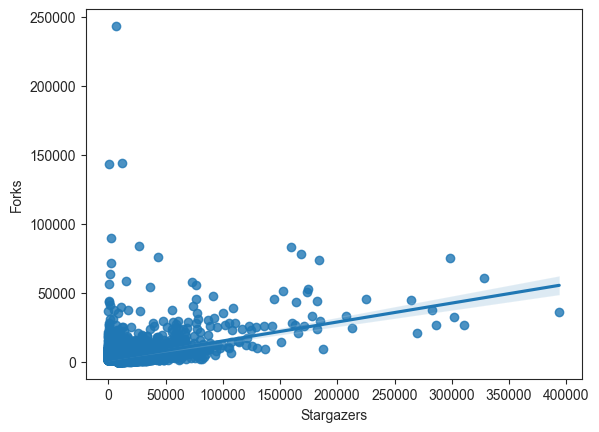

In [97]:
ax = sns.regplot(data=df, x="stargazers_count", y="forks_count")
ax.set_xlabel("Stargazers")
ax.set_ylabel("Forks")
ax

<Axes: xlabel='Watchers', ylabel='Forks'>

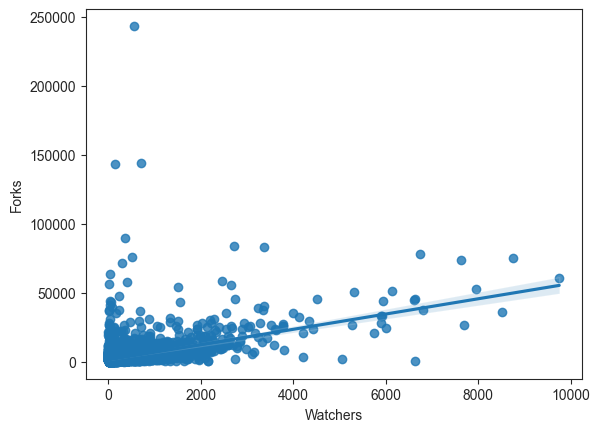

In [98]:
ax = sns.regplot(data=df, x="watchers_count", y="forks_count")
ax.set_xlabel("Watchers")
ax.set_ylabel("Forks")
ax

<Axes: xlabel='Watchers', ylabel='Stargazers'>

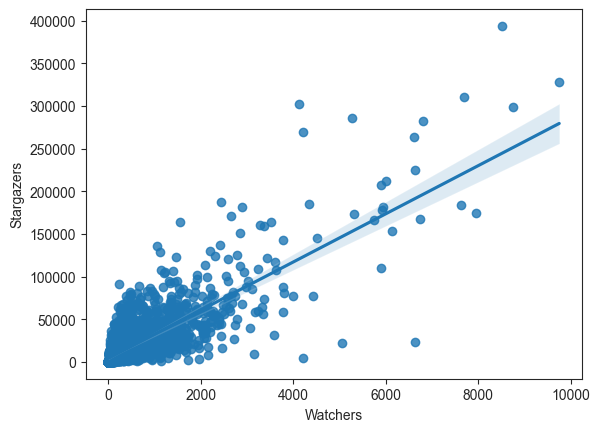

In [99]:
ax = sns.regplot(data=df, x="watchers_count", y="stargazers_count")
ax.set_xlabel("Watchers")
ax.set_ylabel("Stargazers")
ax

There is some correlation between the number of stargazers, watchers and forks, but there are also many outlier points.

## Word Clouds

Finally, we can generate some word clouds.

In [100]:
def show_word_cloud_from_frequencies(frequencies):
    """Shows a word cloud for words based on the provided frequencies."""
    wc = WordCloud(width=1600, height=800, background_color="white", random_state=1).generate_from_frequencies(frequencies)
    plt.figure(figsize=(6, 6), dpi=120)
    plt.imshow(wc, interpolation="bilinear")
    plt.tight_layout(pad=0)
    plt.axis("off")
    plt.show()

def show_word_cloud_from_text(text: str):
    """Shows a word cloud for words based on the provided text."""
    wc = WordCloud(width=1600, height=800, background_color="white", min_word_length=2, random_state=1).generate_from_text(text)
    plt.figure(figsize=(6, 6), dpi=120)
    plt.imshow(wc, interpolation="bilinear")
    plt.tight_layout(pad=0)
    plt.axis("off")
    plt.show()

def convert_to_words(text):
    """Converts the text from various case formats into text with spaces."""
    text = text.replace("-", " ").replace("_", " ")
    text = re.sub(r"(?<=[a-z])(?=[A-Z])", " ", text)
    words = [word.lower() for word in text.split()]
    return " ".join(words)

### Languages

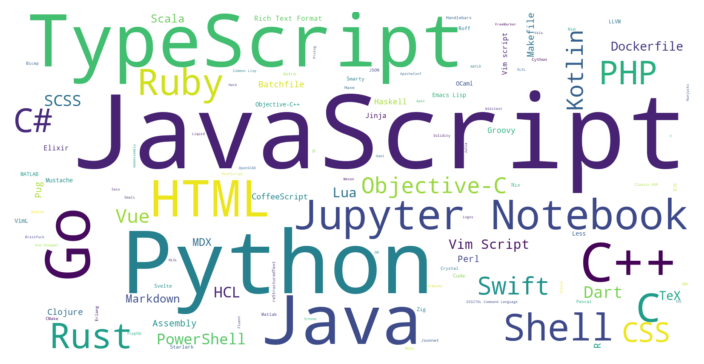

In [101]:
# Word cloud for the main repository languages
show_word_cloud_from_frequencies(df["language"].value_counts())

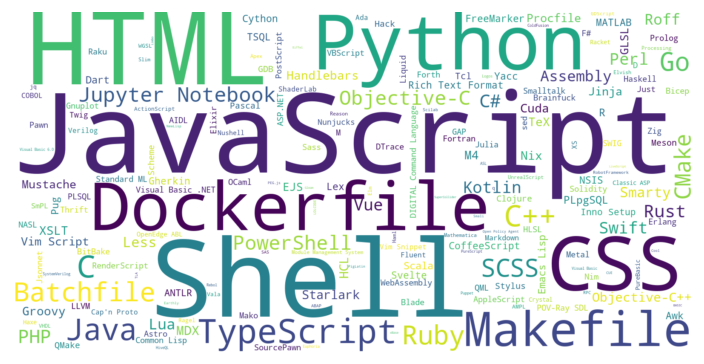

In [102]:
# Word cloud for languages by repositories
show_word_cloud_from_frequencies(languages["repositories"])

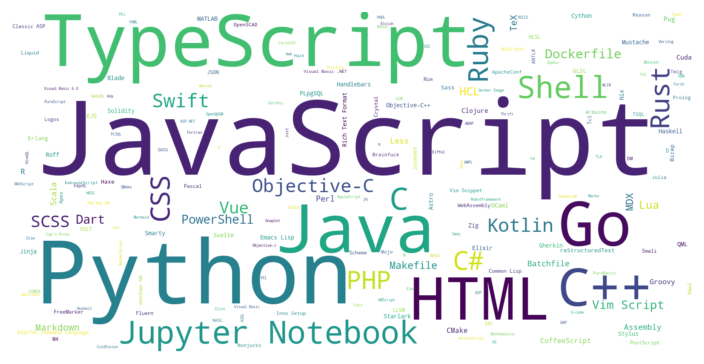

In [103]:
# Word cloud for languages by shares
show_word_cloud_from_frequencies(languages["shares"])

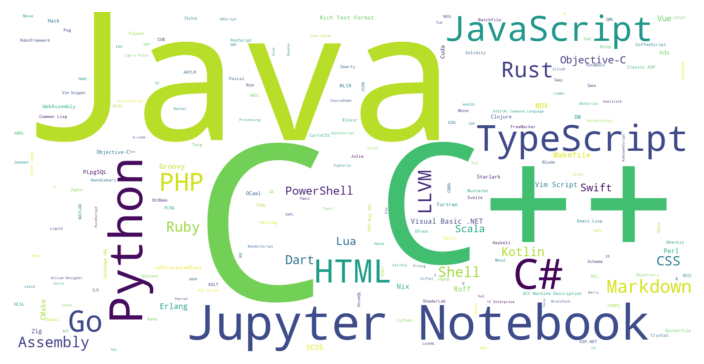

In [104]:
# Word cloud for languages by lines of code
show_word_cloud_from_frequencies(languages["lines"])

### Topics

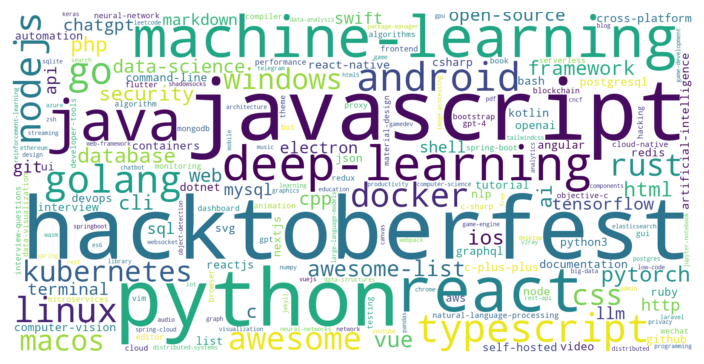

In [105]:
# Word cloud for all repository topics, including common languages
show_word_cloud_from_frequencies(df["topics"].explode().value_counts())

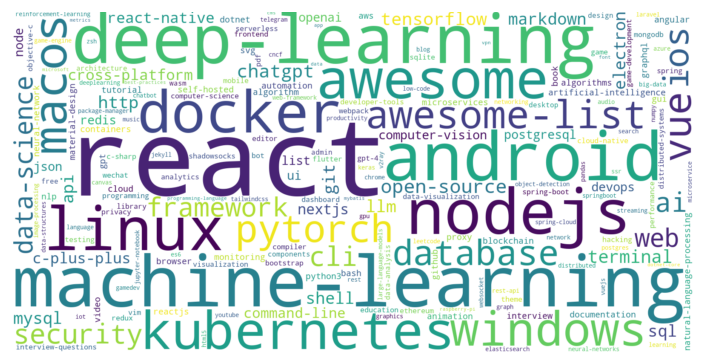

In [106]:
# Word cloud for all repository topics, excluding common languages
show_word_cloud_from_frequencies(remaining_topics)

### Default Branches

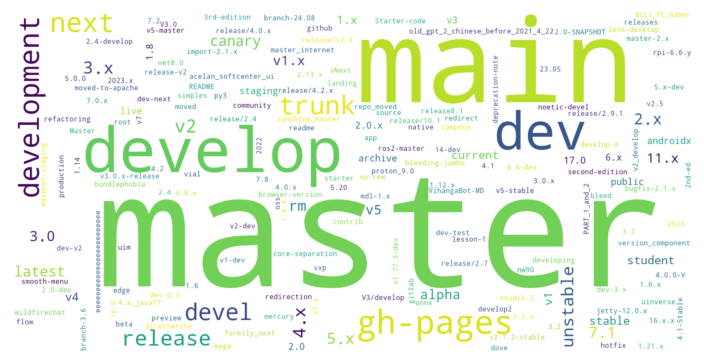

In [107]:
show_word_cloud_from_frequencies(df["default_branch"].value_counts())

### Owners

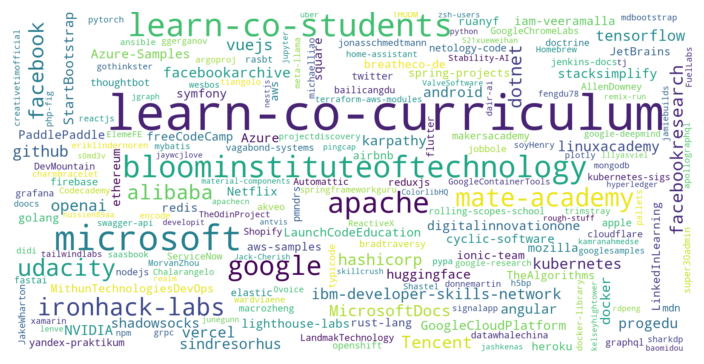

In [108]:
# Word cloud of exact repository owners
show_word_cloud_from_frequencies(df["owner"].value_counts())

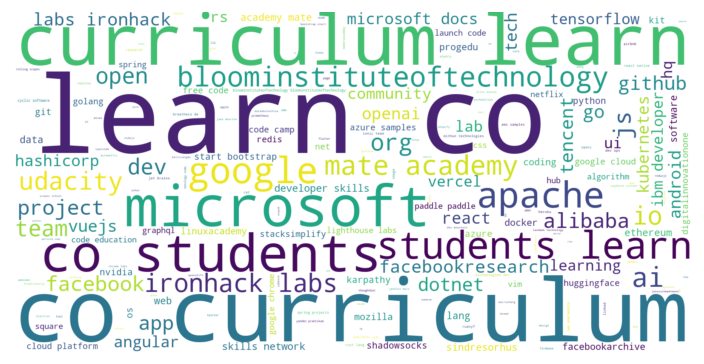

In [109]:
# Word cloud of words in repository owners
show_word_cloud_from_text(convert_to_words(" ".join(df["owner"])))

### Names

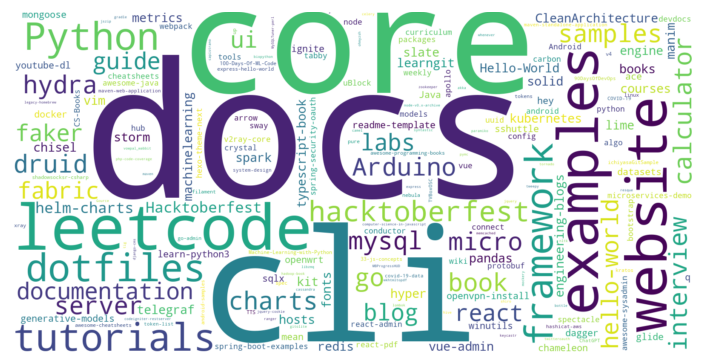

In [110]:
# Word cloud of exact repository names
show_word_cloud_from_frequencies(df["name"].value_counts())

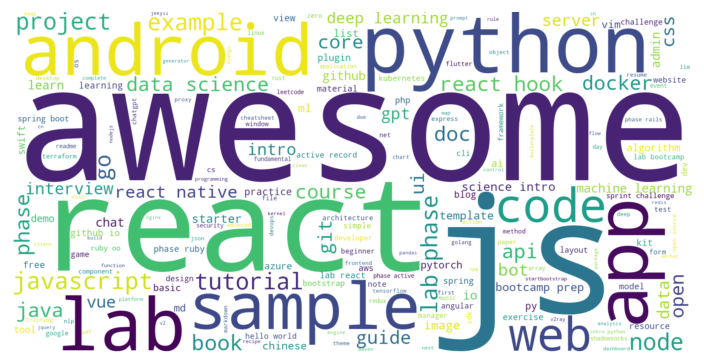

In [111]:
# Word cloud of words in repository names
show_word_cloud_from_text(convert_to_words(" ".join(df["name"])))

### Descriptions

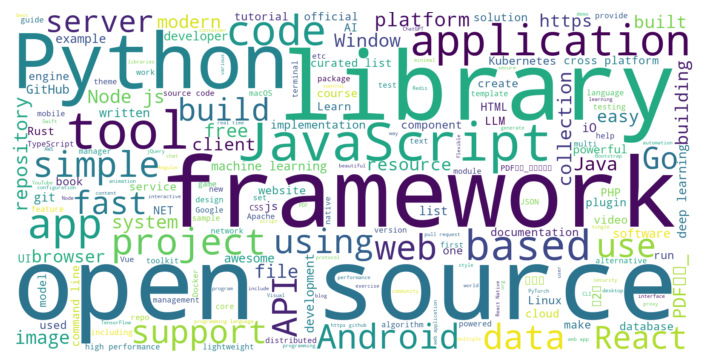

In [112]:
show_word_cloud_from_text(" ".join(df["description"].dropna()))